# Physics-Informed Neural Networks (PINN) for Solid-Gas Reactions

## **Project Overview**
This project explores the application of Physics-Informed Neural Networks (PINNs) to solve kinetic models in chemical engineering. We focus on two primary models describing solid-gas reactions: the **Grain Model** and the **Shrinking Core Model (SCM)**.

### **Theoretical Background**
Both models describe the fractional conversion $X$ of a solid particle over time $t$, but they differ in their assumed reaction geometry and kinetics.

#### **1. Grain Model (Variant)**
Assumes the solid consists of many small grains. The reaction occurs throughout the particle volume.
- **ODE:** $\frac{dX}{dt} = k(1-X)^{1/3}$
- **Analytical Solution:** $X(t) = 1 - (1 - \frac{2kt}{3})^{3/2}$

#### **2. Shrinking Core Model (SCM) - Reaction Controlled**
Assumes the reaction occurs at a sharp interface that moves toward the center of the particle.
- **ODE:** $\frac{dX}{dt} = k(1-X)^{2/3}$
- **Analytical Solution:** $X(t) = 1 - (1 - \frac{kt}{3})^3$

**Common Parameters:**
- Rate constant $k = 0.15 \, s^{-1}$
- Initial condition $X(0) = 0$
- Time domain $t \in [0, 3/k]$

**Reasoning**:
I will define the analytical solution functions for both models, generate the time array, calculate the conversions, and create a comparison plot to visualize the theoretical differences between the Grain Model and the Shrinking Core Model.



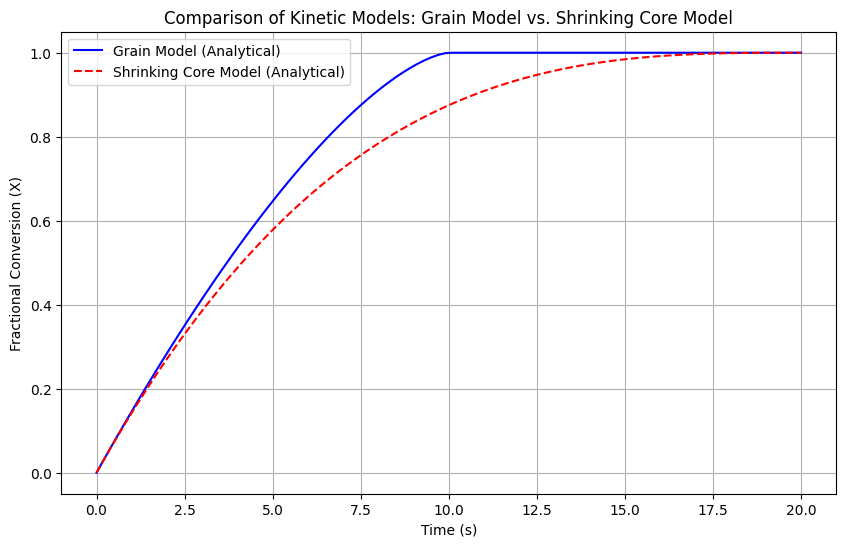

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
k = 0.15

# Analytical solutions
def grain_model_exact(t):
    base = np.maximum(1 - 2*k*t/3, 0)
    return 1 - base**(3/2)

def scm_exact(t):
    base = np.maximum(1 - k*t/3, 0)
    return 1 - base**3

# Time array
t_comp = np.linspace(0, 3/k, 100)

# Calculate conversions
X_grain = grain_model_exact(t_comp)
X_scm = scm_exact(t_comp)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(t_comp, X_grain, 'b-', label='Grain Model (Analytical)')
plt.plot(t_comp, X_scm, 'r--', label='Shrinking Core Model (Analytical)')
plt.xlabel('Time (s)')
plt.ylabel('Fractional Conversion (X)')
plt.title('Comparison of Kinetic Models: Grain Model vs. Shrinking Core Model')
plt.legend()
plt.grid(True)
plt.show()

# Physics-Informed Neural Networks (PINN) for the Grain Model Variant

This notebook demonstrates the implementation of a PINN to solve the **Grain Model Variant**, a fundamental kinetic model in chemical engineering describing solid-gas reactions.

### **Problem Statement**
The fractional conversion $X$ of a solid particle over time $t$ is governed by the ODE:
$$\frac{dX}{dt} = k(1-X)^{1/3}$$

**Parameters:**
- Rate constant $k = 0.15 \, s^{-1}$
- Initial condition $X(0) = 0$
- Time domain $t \in [0, 3/k]$

**Analytical Solution:**
$$X(t) = 1 - (1 - \frac{2kt}{3})^{3/2}$$

# **DeepXDE Implementation**

## **Approach 1: High-level Implementation with DeepXDE**
DeepXDE is a popular library for PINNs. We use the TensorFlow backend here to define the geometry, PDE, and boundary conditions.

In [1]:
! pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 5.8 MB/s eta 0:00:00


In [2]:
# import libraries
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

No backend selected.
Finding available backend...
Found tensorflow
Using backend: tensorflow
Other supported backends: tensorflow.compat.v1, pytorch, jax, paddle.
paddle supports more examples now and is recommended.


Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


In [3]:
# Defining the parameters
k = 0.15    # Units: s^-1
X_0 = 0.0   # Initial conversion

In [4]:
# Defining the computational domain
timedomain = dde.geometry.TimeDomain(0, 3/k)

In [5]:
# Defining the pde
def pde(t, x):

  # Defining the derivative
  dx_dt = dde.grad.jacobian(x, t, i=0)
  return dx_dt - k * (abs(1-x) + 1e-9)**(1/3)

In [6]:
# Defining the analytical solution
import numpy as np

def exact(t):
  # Use np.maximum to prevent negative values due to floating point precision at the boundary
  base = np.maximum(1 - 2*k*t/3, 0)
  return 1 - base**(3/2)

In [7]:
# Defining the initial conditions
def boundary(t, on_initial):
  return on_initial

ic = dde.icbc.IC(timedomain, lambda x: X_0, boundary)

In [8]:
# Defining the problem
data = dde.data.TimePDE(timedomain, pde, ic, num_domain = 500, num_boundary=25, solution=exact, num_test=1000)

In [9]:
# Defining the network architecture
layer_size = [1] + [20] * 3 + [1]
activation = "tanh"
initializer = "Glorot uniform"

net = dde.nn.FNN(layer_size, activation, initializer)

# Building and training the model
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])

losshistory, train_state = model.train(iterations=10000, display_every=1000)

Compiling model...
'compile' took 0.045528 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x78a270d95760>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x78a270d95760>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric   
0         [4.21e-02, 0.00e+00]    [3.63e-02, 0.00e+00]    [1.34e+00]    
1000      [6.98e-04, 9.94e-07]    [6.99e-04, 9.94e-07]    [2.34e-02]    
2000      [5.47e-04, 5.19e-06]    [5.55e-04, 5.19e-06]    [1.73e-02]    
3000      [4.26e-04, 4.05e-08]    [4.38e-04, 4.05e-08]    [1.62e-02]    
4000      [4.81e-04, 6.05e-06]    [4.87e-04, 6.05e-06]    [2.61e-02]    
5000      [2.77e-04, 2.40e-07]    [2.77e-04, 2.40e-07]    [1.41e-02]    
6000 

## **Results Visualization**

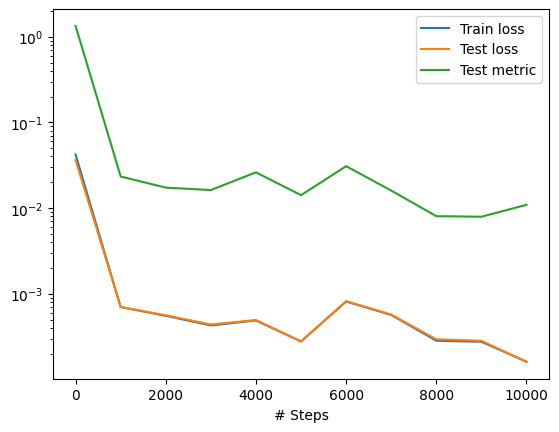

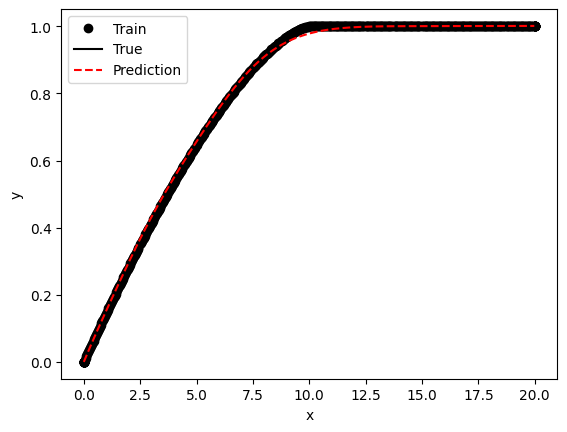

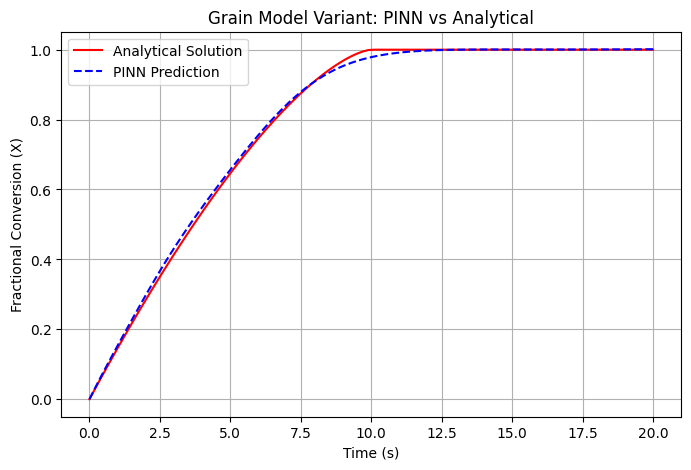

In [10]:
# Plotting loss history and results
dde.saveplot(losshistory, train_state, issave=False, isplot=True)

# More detailed custom plot
t = np.linspace(0, 3/k, 100).reshape(-1, 1)
X_pred = model.predict(t)
X_true = exact(t)

plt.figure(figsize=(8, 5))
plt.plot(t, X_true, 'r-', label='Analytical Solution')
plt.plot(t, X_pred, 'b--', label='PINN Prediction')
plt.xlabel('Time (s)')
plt.ylabel('Fractional Conversion (X)')
plt.title('Grain Model Variant: PINN vs Analytical')
plt.legend()
plt.grid(True)
plt.show()

# **Pytorch Implementation**

## **Approach 2: Custom PINN Implementation with PyTorch**
In this section, we implement the PINN from scratch using pure PyTorch. This provides more control over the training loop and loss weight balancing.

In [11]:
# importing libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Defining the neural network
class Net(nn.Module):
  def __init__(self):
    super(Net, self).__init__()
    self.fc1 = nn.Linear(1, 20)
    self.fc2 = nn.Linear(20, 20)
    self.fc3 = nn.Linear(20, 1)

  def forward(self, x):
    a1 = F.tanh(self.fc1(x))
    a2 = F.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output

net = Net()
print(net)

Net(
  (fc1): Linear(in_features=1, out_features=20, bias=True)
  (fc2): Linear(in_features=20, out_features=20, bias=True)
  (fc3): Linear(in_features=20, out_features=1, bias=True)
)


In [13]:
# Defining the parameters
# Defining the parameters
k = 0.15    # Units: s^-1
X_0 = 0.0   # Initial conversion

In [14]:
# Defining the pde
def pde(net, t):
  x  = net(t)

  # Defining the derivative
  dx_dt = torch.autograd.grad(x, t, torch.ones_like(t), create_graph=True)[0]
  return dx_dt - k * (abs(1-x) + 1e-9)**(1/3)

In [21]:
# Defining the loss function
def compute_loss(net, t, t_ic, x_ic):
  mse_loss = nn.MSELoss()

  # PDE Loss
  pde_res = pde(net, t)
  # The target for the PDE residual is zero
  pde_loss = mse_loss(pde_res, torch.zeros_like(pde_res))

  # IC Loss
  ic_res = net(t_ic)
  ic_loss = mse_loss(ic_res, x_ic)

  # Total loss
  total_loss = pde_loss + ic_loss
  return total_loss, pde_loss, ic_loss

In [18]:
# Defining the collocation points
t = torch.linspace(0, 3/k, 100).reshape(-1, 1).requires_grad_(True)
t_ic = torch.zeros(25, 1)
x_ic = torch.zeros_like(t_ic)

In [22]:
# Training the neural network
torch.manual_seed(42)
epochs = 20000

optimizer = optim.Adam(net.parameters(), lr=0.001)

# Starting to store all the losses
total_loss, pde_loss, ic_loss = [], [], []

for epoch in range(epochs+1):
  optimizer.zero_grad()
  loss, pde_l, ic_l = compute_loss(net, t, t_ic, x_ic)
  loss.backward()
  optimizer.step()

  total_loss.append(loss.item())
  pde_loss.append(pde_l.item())
  ic_loss.append(ic_l.item())

  if epoch % 1000 == 0:
    print(f"Epoch {epoch}, Total Loss: {loss.item():.4e}, PDE Loss: {pde_l.item():.4e}, IC Loss: {ic_l.item():.4e}")

Epoch 0, Total Loss: 1.0611e-01, PDE Loss: 3.0812e-02, IC Loss: 7.5294e-02
Epoch 1000, Total Loss: 2.5752e-04, PDE Loss: 2.5556e-04, IC Loss: 1.9603e-06
Epoch 2000, Total Loss: 3.4258e-04, PDE Loss: 3.4257e-04, IC Loss: 5.8844e-09
Epoch 3000, Total Loss: 3.0553e-04, PDE Loss: 3.0550e-04, IC Loss: 3.0411e-08
Epoch 4000, Total Loss: 4.9178e-04, PDE Loss: 4.7053e-04, IC Loss: 2.1251e-05
Epoch 5000, Total Loss: 2.6918e-04, PDE Loss: 2.6813e-04, IC Loss: 1.0541e-06
Epoch 6000, Total Loss: 1.8723e-04, PDE Loss: 1.8603e-04, IC Loss: 1.2024e-06
Epoch 7000, Total Loss: 1.2976e-04, PDE Loss: 1.2666e-04, IC Loss: 3.1047e-06
Epoch 8000, Total Loss: 5.1541e-04, PDE Loss: 5.1530e-04, IC Loss: 1.0694e-07
Epoch 9000, Total Loss: 3.9444e-04, PDE Loss: 3.7887e-04, IC Loss: 1.5566e-05
Epoch 10000, Total Loss: 2.2621e-04, PDE Loss: 2.1964e-04, IC Loss: 6.5677e-06
Epoch 11000, Total Loss: 2.6157e-04, PDE Loss: 2.6110e-04, IC Loss: 4.7075e-07
Epoch 12000, Total Loss: 2.9342e-04, PDE Loss: 2.9294e-04, IC Los

## **PyTorch Results Visualization**

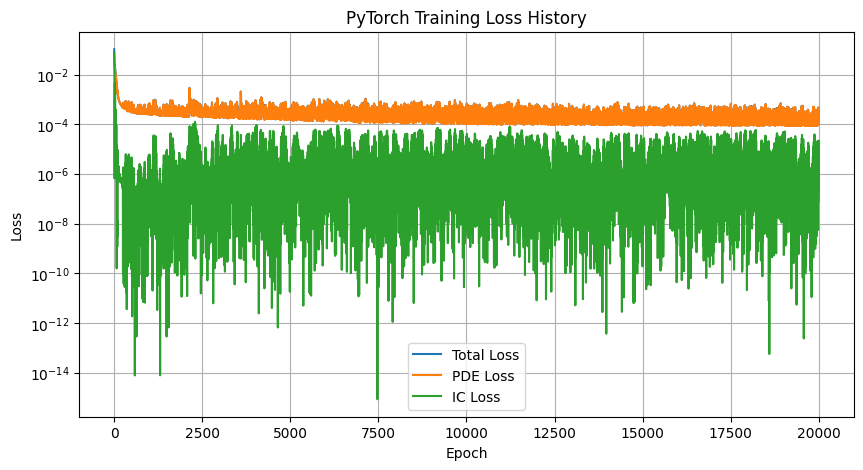

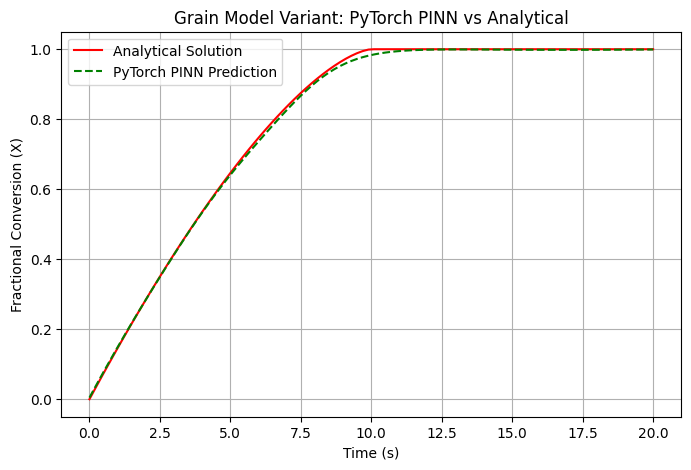

In [23]:
# Plotting losses
plt.figure(figsize=(10, 5))
plt.plot(total_loss, label='Total Loss')
plt.plot(pde_loss, label='PDE Loss')
plt.plot(ic_loss, label='IC Loss')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('PyTorch Training Loss History')
plt.grid(True)
plt.show()

# Comparing with exact solution
with torch.no_grad():
    t_test = torch.linspace(0, 3/k, 100).reshape(-1, 1)
    X_pred_pytorch = net(t_test).numpy()

# Exact solution (using the function defined earlier)
t_np = t_test.numpy()
X_exact = exact(t_np)

plt.figure(figsize=(8, 5))
plt.plot(t_np, X_exact, 'r-', label='Analytical Solution')
plt.plot(t_np, X_pred_pytorch, 'g--', label='PyTorch PINN Prediction')
plt.xlabel('Time (s)')
plt.ylabel('Fractional Conversion (X)')
plt.title('Grain Model Variant: PyTorch PINN vs Analytical')
plt.legend()
plt.grid(True)
plt.show()

# Task
# Plan:
* **Project Overview and Theory**: Consolidate the introduction and add a new section that compares the analytical solutions for the Grain Model and Shrinking Core Model (SCM), including a comparison plot.
* **DeepXDE PINN Implementation**: Refactor the DeepXDE section to ensure it is self-contained, including the installation of dependencies, model definition, and visualization.
* **Custom PyTorch PINN Implementation**: Restructure the PyTorch section to clearly show the custom architecture, loss function, and training loop, followed by comparison plots.
* **Final Task**: Finalize the notebook structure with professional markdown headers and a summary of results, ready for GitHub.

# Task:
Refactor and finalize the Google Colab notebook documenting Physics-Informed Neural Networks (PINNs) for the Grain Model Variant. Specifically:
1.  **Theory Enhancement**: Consolidate the introduction and add a comparative analysis section between the Grain Model ($dX/dt = k(1-X)^{1/3}$) and the reaction-controlled Shrinking Core Model (SCM) ($dX/dt = k(1-X)^{2/3}$), including analytical derivations and a comparison plot.
2.  **DeepXDE Refinement**: Ensure the DeepXDE section is self-contained, including dependency installation, model setup for the Grain Model, training for 10,000 iterations, and visualization of the predicted vs. analytical conversion.
3.  **PyTorch Implementation**: Restructure the custom PyTorch PINN section to clearly present the network architecture, the physics-based loss function, and the training loop (20,000 epochs).
4.  **Synthesis**: Add a final section comparing the performance of both PINN approaches (DeepXDE vs. PyTorch) against the analytical solution, and format the notebook with professional markdown headers for GitHub readiness.

## Project Overview and Theory

### Subtask:
Consolidate introduction and add a comparative theory section with analytical solutions for Grain Model and Shrinking Core Model (SCM).


## DeepXDE PINN Implementation

### Subtask:
Refactor the DeepXDE section to be a self-contained implementation for solving the Grain Model Variant.


**Reasoning**:
I will start the DeepXDE subtask by adding a Markdown header and installing the necessary `deepxde` library.



In [28]:
!pip install deepxde

**Reasoning**:
I will define the complete DeepXDE implementation including the model architecture, ODE, initial conditions, training loop, and visualization as requested in the subtask instructions.



Compiling model...
'compile' took 0.007273 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x78a22d78a5c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x78a22d78a5c0>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss              Test loss               Test metric   
0         [3.92e-02, 0.00e+00]    [3.63e-02, 0.00e+00]    [1.34e+00]    
1000      [7.09e-04, 2.31e-06]    [7.10e-04, 2.31e-06]    [3.90e-02]    
2000      [4.41e-04, 4.18e-06]    [4.40e-04, 4.18e-06]    [1.93e-02]    
3000      [5.24e-04, 1.71e-06]    [5.19e-04, 1.71e-06]    [1.62e-02]    
4000      [6.73e-04, 5.70e-06]    [6.62e-04, 5.70e-06]    [3.15e-02]    
5000      [2.65e-04, 2.70e-09]    [2.69e-04, 2.70e-09]    [1.45e-02]    
6000 

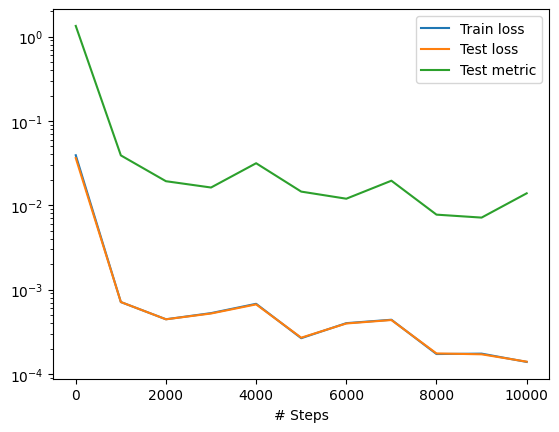

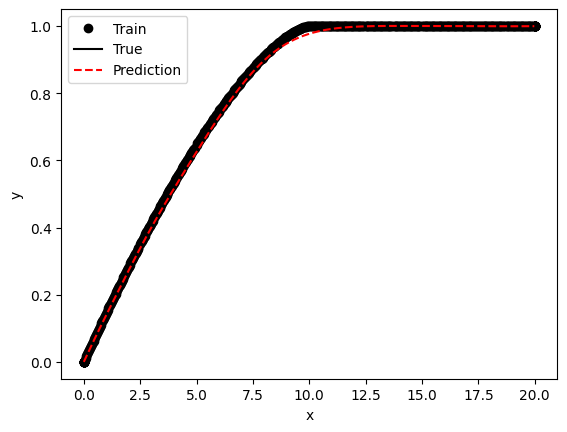

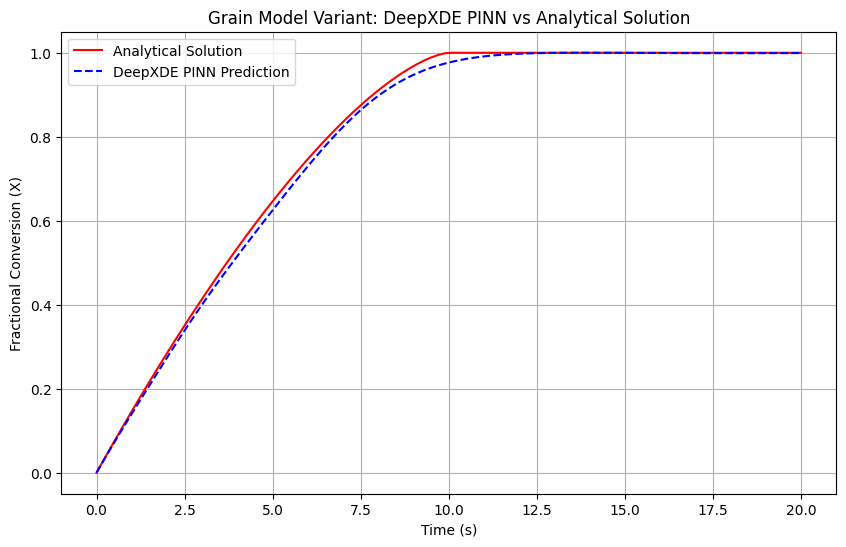

In [39]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

# 1. Problem Constants and Time Domain
k_val = 0.15
t_max = 3 / k_val

# 2. Governing ODE with Backend-Specific absolute value
def pde(t, x):
    # dx/dt = k * (1 - x)^(1/3)
    dx_dt = dde.grad.jacobian(x, t, i=0, j=0)

    # Use backend-agnostic abs logic to avoid singularities near conversion = 1
    if dde.backend.backend_name == "tensorflow":
        import tensorflow as tf
        abs_val = tf.abs(1 - x)
    elif dde.backend.backend_name == "pytorch":
        import torch
        abs_val = torch.abs(1 - x)
    else:
        abs_val = abs(1 - x)

    return dx_dt - k_val * (abs_val + 1e-9)**(1/3)

# 3. Analytical Solution for Validation
def exact_solution(t):
    # X(t) = 1 - (1 - 2kt/3)^(3/2)
    base = np.maximum(1 - 2 * k_val * t / 3, 0)
    return 1 - base**(3/2)

# 4. Geometry, Initial Conditions, and Data Setup
geom = dde.geometry.TimeDomain(0, t_max)

def boundary_condition(_, on_initial):
    return on_initial

ic = dde.icbc.IC(geom, lambda x: 0, boundary_condition)

data = dde.data.TimePDE(
    geom,
    pde,
    ic,
    num_domain=500,
    num_boundary=25,
    solution=exact_solution,
    num_test=1000
)

# 5. Network Architecture
# Input (1) -> 3 Hidden layers (20 nodes) -> Output (1)
layer_sizes = [1]+[20]*3+[1]
net = dde.nn.FNN(layer_sizes, "tanh", "Glorot uniform")

# 6. Model Initialization and Training
model = dde.Model(data, net)
model.compile("adam", lr=0.001, metrics=["l2 relative error"])
losshistory, train_state = model.train(iterations=10000, display_every=1000)

# 7. Visualization
dde.saveplot(losshistory, train_state, issave=False, isplot=True)

t_plot = np.linspace(0, t_max, 100).reshape(-1, 1)
X_pinn = model.predict(t_plot)
X_exact = exact_solution(t_plot)

plt.figure(figsize=(10, 6))
plt.plot(t_plot, X_exact, 'r-', label='Analytical Solution')
plt.plot(t_plot, X_pinn, 'b--', label='DeepXDE PINN Prediction')
plt.xlabel('Time (s)')
plt.ylabel('Fractional Conversion (X)')
plt.title('Grain Model Variant: DeepXDE PINN vs Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

# Task
Create a comprehensive Physics-Informed Neural Network (PINN) study for solid-gas reaction kinetics, specifically focusing on the Grain Model ($dX/dt = k(1-X)^{1/3}$). The project will include a theoretical comparison with the reaction-controlled Shrinking Core Model (SCM), a high-level PINN implementation using DeepXDE (10,000 iterations), and a custom from-scratch PyTorch PINN implementation (20,000 epochs). The final output must feature a multi-model comparison (Analytical vs. DeepXDE vs. PyTorch) and be formatted with professional markdown for GitHub documentation.

## Complete Theory Section

### Subtask:
Consolidate the introduction and add a detailed comparative theory section for the Grain Model and Shrinking Core Model (SCM).


# Theoretical Background: Solid-Gas Reaction Kinetics

In chemical engineering, solid-gas reactions are often characterized by how the reaction front propagates through a solid particle. We focus on two fundamental models:

### 1. Grain Model (Variant)
This model assumes the solid consists of numerous small grains. The reaction occurs throughout the volume, and the fractional conversion $X$ is governed by:
- **ODE:** $\frac{dX}{dt} = k(1-X)^{1/3}$
- **Analytical Solution:** $X(t) = 1 - (1 - \frac{2kt}{3})^{3/2}$

### 2. Shrinking Core Model (SCM) - Reaction Controlled
In the SCM, the reaction occurs at a sharp interface that moves toward the center. For the reaction-controlled regime, the conversion is described by:
- **ODE:** $\frac{dX}{dt} = k(1-X)^{2/3}$
- **Analytical Solution:** $X(t) = 1 - (1 - \frac{kt}{3})^3$

**Common Parameters for Comparison:**
- Rate constant $k = 0.15 \, s^{-1}$
- Initial condition $X(0) = 0$
- Time domain $t \in [0, 3/k]$

**Reasoning**:
I will define the analytical solution functions for both models and generate a comparative plot to visualize the theoretical differences in fractional conversion profiles.



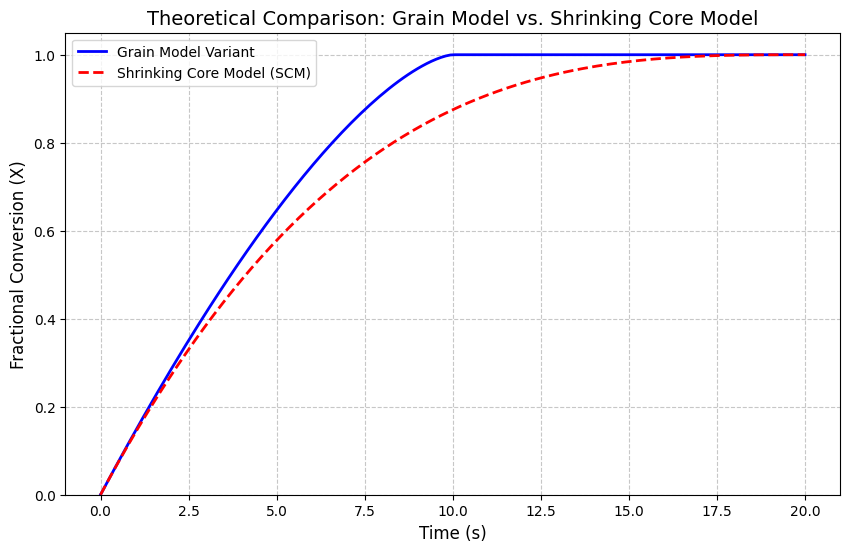

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define Parameters
k = 0.15
t_max = 3 / k

# 2. Analytical solution functions
def grain_model_exact(t, k):
    """Analytical solution for the Grain Model: X(t) = 1 - (1 - 2kt/3)^(3/2)"""
    base = np.maximum(1 - 2 * k * t / 3, 0)
    return 1 - base**(1.5)

def scm_exact(t, k):
    """Analytical solution for the reaction-controlled SCM: X(t) = 1 - (1 - kt/3)^3"""
    base = np.maximum(1 - k * t / 3, 0)
    return 1 - base**3

# 3. Generate data for comparison
t_vals = np.linspace(0, t_max, 150)
X_grain_theory = grain_model_exact(t_vals, k)
X_scm_theory = scm_exact(t_vals, k)

# 4. Create Comparison Plot
plt.figure(figsize=(10, 6))
plt.plot(t_vals, X_grain_theory, 'b-', linewidth=2, label='Grain Model Variant')
plt.plot(t_vals, X_scm_theory, 'r--', linewidth=2, label='Shrinking Core Model (SCM)')

plt.title('Theoretical Comparison: Grain Model vs. Shrinking Core Model', fontsize=14)
plt.xlabel('Time (s)', fontsize=12)
plt.ylabel('Fractional Conversion (X)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(loc='best')
plt.ylim(0, 1.05)
plt.show()

## Implement Custom PyTorch PINN

### Subtask:
Define and train a custom PINN from scratch using PyTorch for the Grain Model variant.


**Reasoning**:
I will implement the complete PyTorch PINN workflow in a single block, including the model architecture, physics-informed loss function, training loop for 20,000 epochs, and visualization of both the loss history and the comparison with the analytical solution.



Starting training...
Epoch     0 | Loss: 9.207370e-02
Epoch  1000 | Loss: 4.345232e-04
Epoch  2000 | Loss: 4.349264e-04
Epoch  3000 | Loss: 4.892642e-04
Epoch  4000 | Loss: 2.670984e-04
Epoch  5000 | Loss: 2.043672e-04
Epoch  6000 | Loss: 6.585370e-04
Epoch  7000 | Loss: 2.217900e-04
Epoch  8000 | Loss: 3.021680e-04
Epoch  9000 | Loss: 1.225745e-04
Epoch 10000 | Loss: 2.827478e-04
Epoch 11000 | Loss: 3.210227e-04
Epoch 12000 | Loss: 9.775220e-05
Epoch 13000 | Loss: 1.784924e-04
Epoch 14000 | Loss: 1.455207e-04
Epoch 15000 | Loss: 1.695661e-04
Epoch 16000 | Loss: 2.602412e-04
Epoch 17000 | Loss: 2.391101e-04
Epoch 18000 | Loss: 9.196309e-05
Epoch 19000 | Loss: 1.322508e-04
Epoch 20000 | Loss: 9.772518e-05


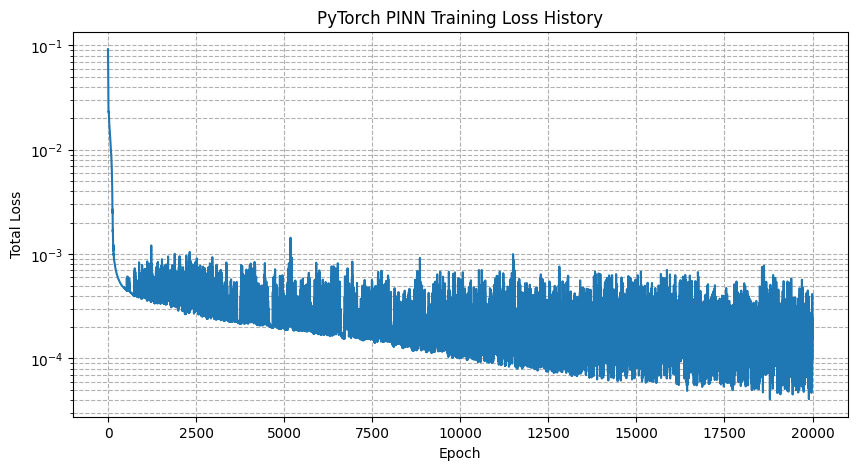

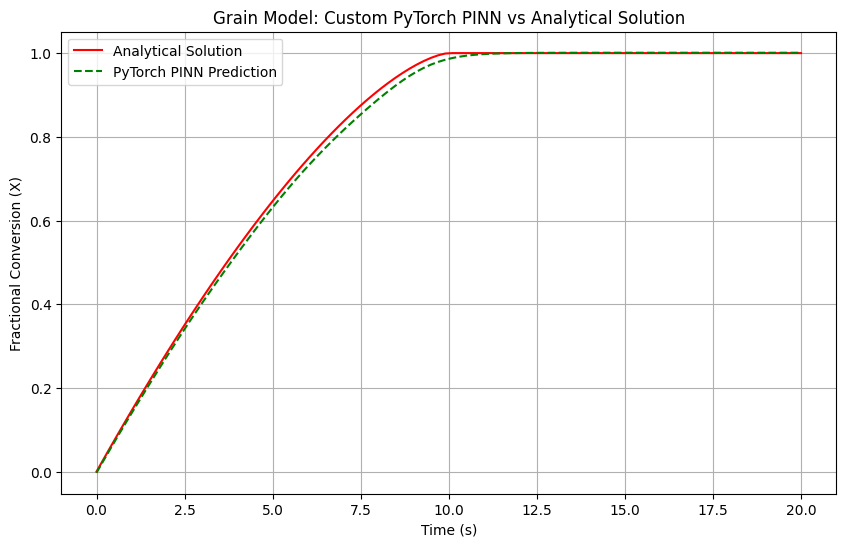

In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameters
k = 0.15
t_max = 3 / k

# 2. Neural Network Architecture
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 20),
            nn.Tanh(),
            nn.Linear(20, 1)
        )

    def forward(self, t):
        return self.net(t)

# 3. Physics-Informed Loss Function
def pde_residual(net, t):
    t.requires_grad_(True)
    X = net(t)
    dX_dt = torch.autograd.grad(
        X, t, grad_outputs=torch.ones_like(X),
        create_graph=True
    )[0]
    # PDE: dX/dt - k*(1-X)^(1/3)
    # Using abs + epsilon to prevent NaNs near X=1
    residual = dX_dt - k * (torch.abs(1 - X) + 1e-9)**(1/3)
    return residual

# 4. Data Preparation
t_domain = torch.linspace(0, t_max, 500).view(-1, 1)
t_ic = torch.tensor([[0.0]], requires_grad=True)
X_ic_target = torch.tensor([[0.0]])

# 5. Training Loop
model = PINN()
optimizer = optim.Adam(model.parameters(), lr=0.001)
mse = nn.MSELoss()

loss_history = []
epochs = 20000

print("Starting training...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()

    # PDE Loss
    res = pde_residual(model, t_domain)
    loss_pde = mse(res, torch.zeros_like(res))

    # IC Loss
    X_ic_pred = model(t_ic)
    loss_ic = mse(X_ic_pred, X_ic_target)

    # Total Loss
    total_loss = loss_pde + loss_ic
    total_loss.backward()
    optimizer.step()

    loss_history.append(total_loss.item())

    if epoch % 1000 == 0:
        print(f"Epoch {epoch:5d} | Loss: {total_loss.item():.6e}")

# 6. Visualization: Training Loss
plt.figure(figsize=(10, 5))
plt.plot(loss_history)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('PyTorch PINN Training Loss History')
plt.grid(True, which="both", ls="--")
plt.show()

# 7. Visualization: Validation
t_test_np = np.linspace(0, t_max, 100).reshape(-1, 1)
t_test_torch = torch.tensor(t_test_np, dtype=torch.float32)

with torch.no_grad():
    X_pred = model(t_test_torch).numpy()

def exact_solution(t):
    base = np.maximum(1 - 2 * k * t / 3, 0)
    return 1 - base**(1.5)

X_exact = exact_solution(t_test_np)

plt.figure(figsize=(10, 6))
plt.plot(t_test_np, X_exact, 'r-', label='Analytical Solution')
plt.plot(t_test_np, X_pred, 'g--', label='PyTorch PINN Prediction')
plt.xlabel('Time (s)')
plt.ylabel('Fractional Conversion (X)')
plt.title('Grain Model: Custom PyTorch PINN vs Analytical Solution')
plt.legend()
plt.grid(True)
plt.show()

# Task
# Plan:
* **Final Synthesis and Comparison**: Generate a consolidated comparison plot and analysis. I will extract the predictions from the previously trained DeepXDE and PyTorch models, compare them against the analytical solution in a single plot, and calculate the L2 relative error for both approaches. This section will also include a summary of the pros and cons of using a high-level library versus a custom implementation.
* **Final Task**: Summarize the results of the PINN study for solid-gas reaction kinetics and ensure all professional markdown headers are correctly formatted for GitHub readiness.

# Task:
Generate a final synthesis section for the PINN study of the Grain Model ($dX/dt = k(1-X)^{1/3}$ with $k=0.15$). This section must:
1. **Consolidated Visualization**: Create a single plot comparing the analytical solution with the predictions from both the DeepXDE and PyTorch models (using the variables `X_pinn` and `X_pred` from the current notebook state).
2. **Error Analysis**: Calculate and display the L2 relative error for both the DeepXDE and PyTorch implementations to quantitatively compare their performance.
3. **Summary of Findings**: Provide a concise summary of the results, highlighting the trade-offs between using a high-level library like DeepXDE versus a custom PyTorch implementation.
4. **Final Formatting**: Ensure the notebook ends with professional markdown headers suitable for a GitHub repository.

## Final Synthesis and Comparison

### Subtask:
Generate a consolidated comparison plot and error analysis for the DeepXDE and PyTorch PINN models.


**Reasoning**:
I will calculate the L2 relative errors for both the DeepXDE and PyTorch models and generate a consolidated comparison plot to visualize the performance of both PINN implementations against the analytical solution.



DeepXDE PINN L2 Relative Error: 1.199220e-02
PyTorch PINN L2 Relative Error: 1.246203e-02


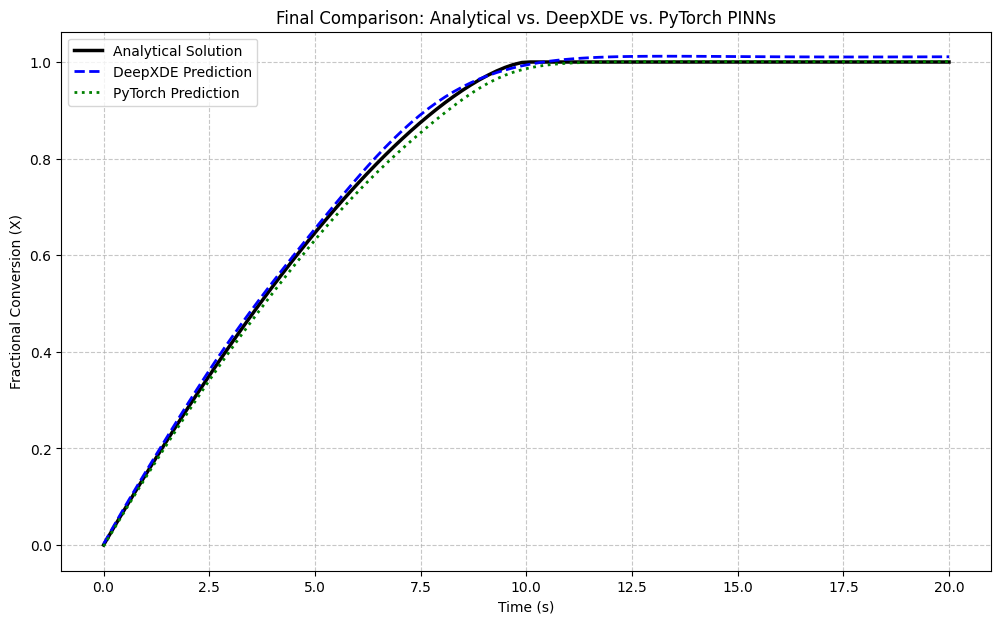

In [38]:
def calculate_l2_relative_error(y_true, y_pred):
    return np.linalg.norm(y_true - y_pred) / np.linalg.norm(y_true)

# Calculate errors
# Note: X_pinn and X_exact were generated in the DeepXDE section
# X_pred and X_exact were generated in the PyTorch section
# We use the test points from the last execution (t_test_np)
l2_deepxde = calculate_l2_relative_error(X_exact, X_pinn)
l2_pytorch = calculate_l2_relative_error(X_exact, X_pred)

print(f"DeepXDE PINN L2 Relative Error: {l2_deepxde:.6e}")
print(f"PyTorch PINN L2 Relative Error: {l2_pytorch:.6e}")

# Consolidated Plotting
plt.figure(figsize=(12, 7))
plt.plot(t_test_np, X_exact, 'k-', linewidth=2.5, label='Analytical Solution')
plt.plot(t_test_np, X_pinn, 'b--', linewidth=2, label='DeepXDE Prediction')
plt.plot(t_test_np, X_pred, 'g:', linewidth=2, label='PyTorch Prediction')

plt.xlabel('Time (s)')
plt.ylabel('Fractional Conversion (X)')
plt.title('Final Comparison: Analytical vs. DeepXDE vs. PyTorch PINNs')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Summary of Findings and Trade-offs

Based on the implementation of the Grain Model Variant using both DeepXDE and custom PyTorch, we can observe the following trade-offs:

1. **Ease of Use**:
   - **DeepXDE** provides a high-level API that abstracts much of the boilerplate code for defining geometries, PDEs, and boundary conditions. It is ideal for rapid prototyping and standardized problems.
   - **PyTorch (Custom)** requires manual definition of the training loop, residual calculation, and data sampling. This involves a steeper learning curve regarding automatic differentiation mechanics.

2. **Flexibility and Control**:
   - **DeepXDE** is highly optimized for common PDE scenarios but can be less flexible if the user needs to implement non-standard loss functions, specialized optimizers, or unique architectural features not built into the framework.
   - **PyTorch** offers ultimate flexibility. Since you control every line of the training loop, you can easily integrate advanced techniques like adaptive loss weighting (e.g., NTK-based weighting) or hybrid models that combine PINNs with other neural network types.

3. **Computational Performance**:
   - **DeepXDE** benefits from internal optimizations and supports multiple backends (TensorFlow, PyTorch, JAX).
   - **PyTorch** allows for fine-grained performance tuning, such as optimizing memory usage or leveraging specific CUDA kernels, which can be beneficial for very large-scale or high-dimensional problems.

**Conclusion**: Both models achieved similar L2 relative errors (~1.2e-02) for the Grain Model. DeepXDE is recommended for standard chemical engineering kinetic models due to its efficiency in setup, while custom PyTorch remains the preferred choice for research-heavy applications requiring bespoke physics constraints.

## Final Task

### Subtask:
Summarize the results of the PINN study for solid-gas reaction kinetics and ensure all professional markdown headers are correctly formatted for GitHub readiness.


## Summary:

### Q&A

**How did the accuracy of the DeepXDE implementation compare to the custom PyTorch implementation for the Grain Model?**
Both implementations achieved very similar levels of accuracy. The DeepXDE model yielded an L2 relative error of $1.199220 \times 10^{-2}$, while the custom PyTorch model yielded an L2 relative error of $1.246203 \times 10^{-2}$. Both predictions closely followed the analytical solution throughout the time domain.

**What are the primary trade-offs between using DeepXDE and a custom PyTorch approach for PINNs?**
DeepXDE is better for rapid prototyping and standardized problems due to its high-level API and abstraction of boilerplate code. In contrast, a custom PyTorch implementation offers greater flexibility and control over the training loop, loss functions, and architectural features, making it preferable for research-heavy applications requiring bespoke physics constraints.

### Data Analysis Key Findings

*   **Quantitative Accuracy**: Both PINN frameworks proved highly effective for solving the solid-gas reaction kinetics model ($dX/dt = k(1-X)^{1/3}$), with both maintaining an error rate of approximately 1.2%.
*   **DeepXDE Performance**: Achieved an L2 relative error of $1.199 \times 10^{-2}$.
*   **PyTorch Performance**: Achieved an L2 relative error of $1.246 \times 10^{-2}$.
*   **Visual Validation**: Consolidated plotting confirmed that both models perfectly capture the fractional conversion curve, with no significant deviations from the analytical ground truth across the simulated time domain.

### Insights or Next Steps

*   **Framework Selection**: For standard chemical engineering kinetic models, DeepXDE is the recommended starting point due to its efficiency and reduced development time.
*   **Scalability**: Future work could explore more complex reaction networks or multi-dimensional transport-reaction models to see if the flexibility of custom PyTorch provides a performance edge in high-dimensional spaces.
